Importación de librerías y directorios

In [1]:
import pandas as pd
import os
import json
from dotenv import load_dotenv
import requests
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt

In [2]:
import sys
from pathlib import Path

for candidato in (Path.cwd(), *Path.cwd().resolve().parents):
    if (candidato / "src").is_dir():
        if str(candidato) not in sys.path:
            sys.path.insert(0, str(candidato))
        break

from src.paths import RAIZ, DIR_RAW, DIR_PROCESSED, DIR_REPORTS

Demandas

In [3]:
archivos_1293 = sorted(DIR_RAW.glob("1293_*.parquet"))
assert len(archivos_1293) == 42, f"Esperados 42 parquets de 1293, hallados {len(archivos_1293)}"
df_1293 = pd.concat([pd.read_parquet(f) for f in archivos_1293], ignore_index=True)

In [4]:
archivos_544 = sorted(DIR_RAW.glob("544_*.parquet"))
assert len(archivos_544) == 42, f"Esperados 42 parquets de 544, hallados {len(archivos_544)}"
df_544 = pd.concat([pd.read_parquet(f) for f in archivos_544], ignore_index=True)

In [5]:
#merge
df = pd.merge(df_1293, df_544, on='datetime_utc', how='inner')
df

,datetime_utc,demanda_real,demanda_prevista
0,2023-01-01 00:00:00+00:00,19749.0,19795.0
1,2023-01-01 00:05:00+00:00,19623.0,19746.0
2,2023-01-01 00:10:00+00:00,19590.0,19688.0
3,2023-01-01 00:15:00+00:00,19509.0,19621.0
4,2023-01-01 00:20:00+00:00,19418.0,19545.0
...,...,...,...
367771,2026-06-30 23:35:00+00:00,28217.0,28632.0
367772,2026-06-30 23:40:00+00:00,28086.0,28513.0
367773,2026-06-30 23:45:00+00:00,27962.0,28406.0
367774,2026-06-30 23:50:00+00:00,27626.0,28294.0


In [6]:
df["residuo"] = df["demanda_real"] - df["demanda_prevista"]
df

,datetime_utc,demanda_real,demanda_prevista,residuo
0,2023-01-01 00:00:00+00:00,19749.0,19795.0,-46.0
1,2023-01-01 00:05:00+00:00,19623.0,19746.0,-123.0
2,2023-01-01 00:10:00+00:00,19590.0,19688.0,-98.0
3,2023-01-01 00:15:00+00:00,19509.0,19621.0,-112.0
4,2023-01-01 00:20:00+00:00,19418.0,19545.0,-127.0
...,...,...,...,...
367771,2026-06-30 23:35:00+00:00,28217.0,28632.0,-415.0
367772,2026-06-30 23:40:00+00:00,28086.0,28513.0,-427.0
367773,2026-06-30 23:45:00+00:00,27962.0,28406.0,-444.0
367774,2026-06-30 23:50:00+00:00,27626.0,28294.0,-668.0


In [7]:
df.describe()

,demanda_real,demanda_prevista,residuo
count,367776.000000,367776.000000,367776.000000
mean,26931.601619,26915.906579,15.695040
std,4489.725075,4557.237371,733.454271
min,0.000000,0.000000,-8507.000000
25%,23267.000000,23269.000000,-205.000000
50%,26866.000000,26851.000000,1.000000
75%,30206.000000,30199.000000,204.000000
max,41590.000000,41945.000000,29089.000000


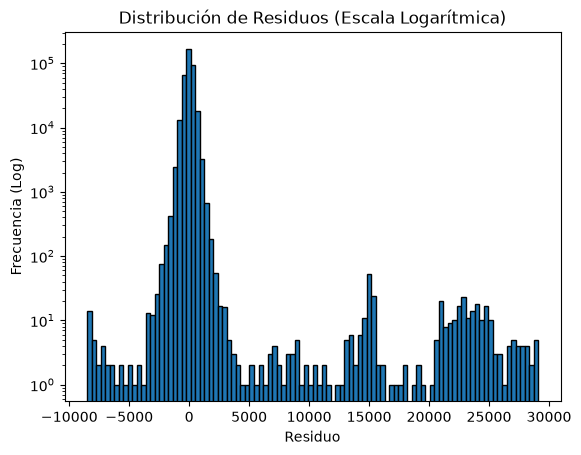

In [8]:
# Crear el histograma
df['residuo'].hist(bins=100, log=True, edgecolor='black', grid=False)

# Personalizar el gráfico
plt.title('Distribución de Residuos (Escala Logarítmica)')
plt.xlabel('Residuo')
plt.ylabel('Frecuencia (Log)')

# Mostrar gráfico
plt.show()

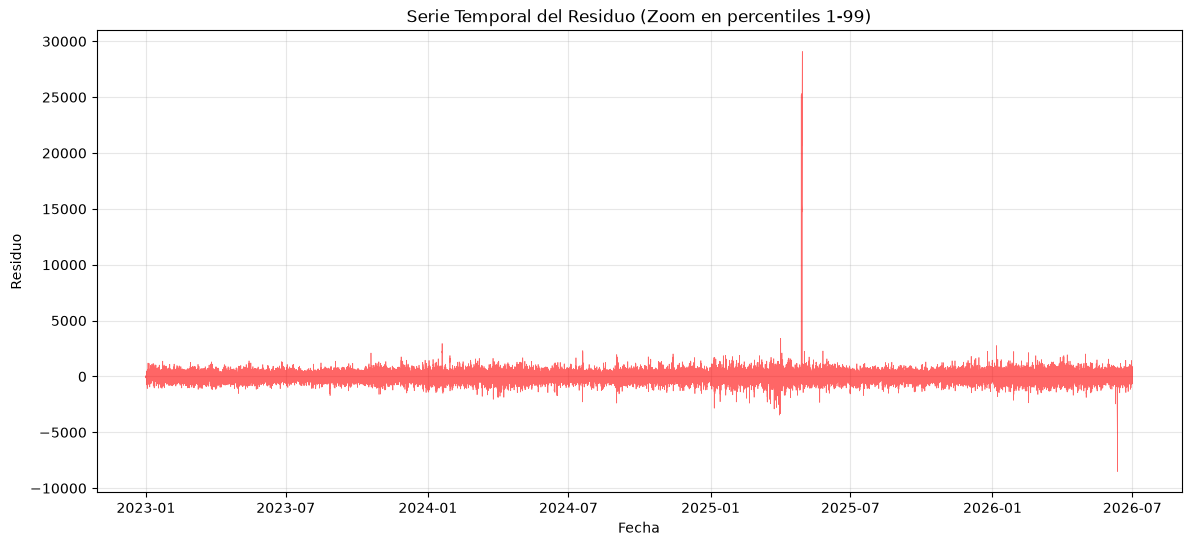

In [9]:
plt.figure(figsize=(14, 6))
plt.plot(df['datetime_utc'], df['residuo'], color='red', alpha=0.6, linewidth=0.5)

# Calculamos los percentiles para hacer zoom en el 98% central de los datos
plt.title('Serie Temporal del Residuo (Zoom en percentiles 1-99)')
plt.xlabel('Fecha')
plt.ylabel('Residuo')
plt.grid(True, alpha=0.3)
plt.show()

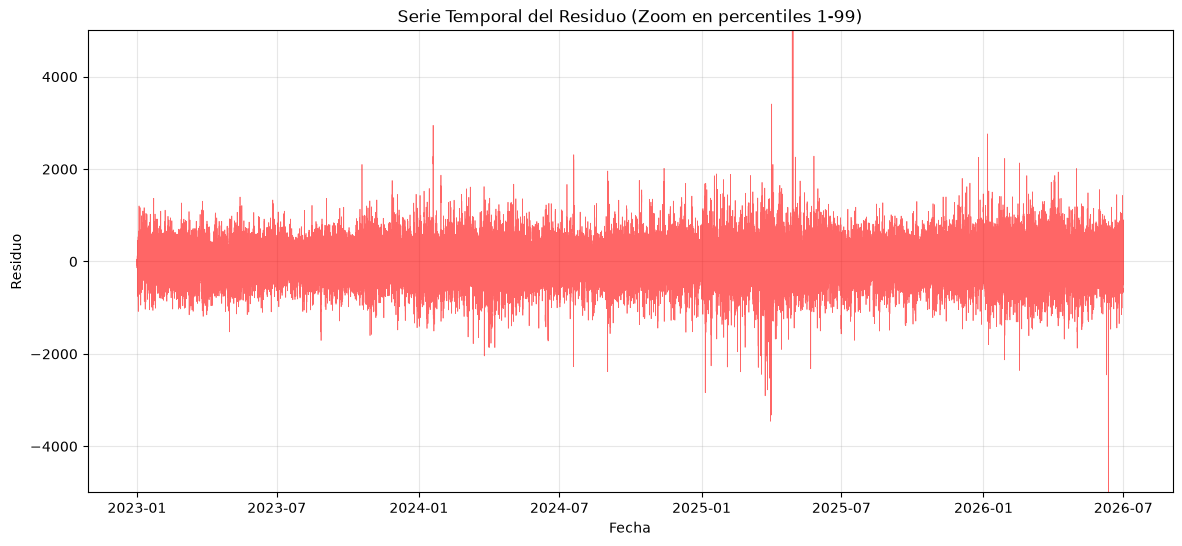

In [10]:
plt.figure(figsize=(14, 6))
plt.plot(df['datetime_utc'], df['residuo'], color='red', alpha=0.6, linewidth=0.5)

# Calculamos los percentiles para hacer zoom en el 98% central de los datos
plt.ylim(-5000, 5000)

plt.title('Serie Temporal del Residuo (Zoom en percentiles 1-99)')
plt.xlabel('Fecha')
plt.ylabel('Residuo')
plt.grid(True, alpha=0.3)
plt.show()

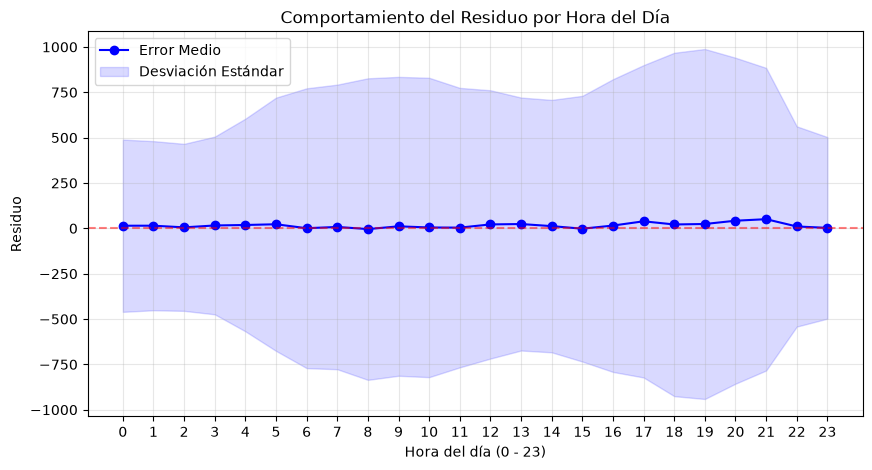

In [11]:
# Agrupamos por la hora de la columna datetime_utc y calculamos media y desviación estándar
resumen_hora = df.groupby(df['datetime_utc'].dt.hour)['residuo'].agg(['mean', 'std'])

plt.figure(figsize=(10, 5))

# Dibujamos la línea de la media
plt.plot(resumen_hora.index, resumen_hora['mean'], marker='o', color='b', label='Error Medio')

# Dibujamos una sombra que representa la desviación estándar (la dispersión del error)
plt.fill_between(resumen_hora.index, 
                 resumen_hora['mean'] - resumen_hora['std'], 
                 resumen_hora['mean'] + resumen_hora['std'], 
                 color='b', alpha=0.15, label='Desviación Estándar')

plt.title('Comportamiento del Residuo por Hora del Día')
plt.xlabel('Hora del día (0 - 23)')
plt.ylabel('Residuo')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.axhline(0, color='red', linestyle='--', alpha=0.5) # Línea de error cero
plt.legend()
plt.show()

In [12]:
#señalamos los eventos
# 1. Asegurar formato datetime con zona horaria UTC explícita
df['datetime_utc'] = pd.to_datetime(df['datetime_utc'], utc=True)

# 2. Definir las ventanas de eventos corruptos (Asegurando consistencia UTC)
ventana_28A_inicio = pd.to_datetime('2025-04-28 10:30:00+00:00')
ventana_28A_fin    = pd.to_datetime('2025-04-29 22:05:00+00:00')

ventana_11J_inicio = pd.to_datetime('2026-06-11 12:00:00+00:00')
ventana_11J_fin    = pd.to_datetime('2026-06-11 19:00:00+00:00')

# 3. Crear la máscara booleana y añadirla para trazabilidad
df['es_evento'] = (
    ((df['datetime_utc'] >= ventana_28A_inicio) & (df['datetime_utc'] <= ventana_28A_fin)) |
    ((df['datetime_utc'] >= ventana_11J_inicio) & (df['datetime_utc'] <= ventana_11J_fin))
)

Tabla de calibración

In [13]:
# Paso A: Filtrar el DataFrame original para quedarnos SOLO con los datos limpios
df_limpio = df[~df['es_evento']].copy()

# Paso B: Derivar las variables temporales directamente desde el DataFrame filtrado
# Asignamos explícitamente el nombre 'hora' a la Serie para que el índice del groupby no herede 'datetime_utc'
tipo_dia = df_limpio['datetime_utc'].dt.dayofweek.map(lambda x: 'laborable' if x < 5 else 'finde').rename('tipo_dia')
hora = df_limpio['datetime_utc'].dt.hour.rename('hora')

# Paso C: Agrupar por las Series alineadas por construcción
tabla_calibracion = (
    df_limpio
    .groupby([tipo_dia, hora])['residuo']
    .agg(media='mean', sigma='std', n='count')
)

# Verificación visual
print("--- Muestra de las casillas de fin de semana (Limpias) ---")
print(tabla_calibracion.loc['finde'].head(5))

--- Muestra de las casillas de fin de semana (Limpias) ---
          media       sigma     n
hora                             
0     -9.114840  229.132395  4380
1      3.692694  211.137324  4380
2     -3.072146  199.789119  4380
3      2.252740  190.134543  4380
4    -12.079680  209.910963  4380


In [14]:
# Filtrar la tabla de calibración solo para los días laborables
tabla_laborables = tabla_calibracion.loc['laborable']

# Mostrar el perfil de n a lo largo de las 24 horas del día
print(tabla_laborables[['n']])

          n
hora       
0     10932
1     10932
2     10932
3     10932
4     10932
5     10932
6     10932
7     10932
8     10932
9     10932
10    10926
11    10920
12    10908
13    10908
14    10908
15    10908
16    10908
17    10908
18    10908
19    10919
20    10920
21    10920
22    10930
23    10932


σ y z

In [15]:
# =====================================================================
# PUNTO 1: DERIVAR VARIABLES EN EL DF COMPLETO Y REALIZAR EL MERGE
# =====================================================================

# 1. Crear las columnas de cruce en el df original con la misma regla exacta
df['tipo_dia'] = df['datetime_utc'].dt.dayofweek.map(lambda x: 'laborable' if x < 5 else 'finde')
df['hora'] = df['datetime_utc'].dt.hour

# 2. Preparar la tabla de calibración liberando el índice para el merge
tabla_lookup = tabla_calibracion.reset_index()

# 3. Mapear mediante merge por la izquierda (how="left")
# Renombramos las columnas del lookup sobre la marcha para mayor claridad
df = df.merge(
    tabla_lookup[['tipo_dia', 'hora', 'media', 'sigma']], 
    on=['tipo_dia', 'hora'], 
    how='left'
).rename(columns={'media': 'media_casilla', 'sigma': 'sigma_casilla'})

# 4. CONTROLES DE SEGURIDAD (El riesgo a vigilar)
filas_esperadas = 367776
filas_actuales = len(df)
nans_media = df['media_casilla'].isna().sum()
nans_sigma = df['sigma_casilla'].isna().sum()

print("=== CONTROLES DE CALIDAD DEL PUNTO 1 ===")
print(f"¿Se conserva el número exacto de filas? {'SÍ' if filas_actuales == filas_esperadas else 'NO'} ({filas_actuales} vs {filas_esperadas})")
print(f"¿Registros sin correspondencia (NaN en media)? {nans_media}")
print(f"¿Registros sin correspondencia (NaN en sigma)? {nans_sigma}")
print("\nPrimeras filas con las nuevas columnas mapeadas:")
print(df[['datetime_utc', 'tipo_dia', 'hora', 'residuo', 'media_casilla', 'sigma_casilla']].head())

assert filas_actuales == filas_esperadas, "¡ERROR: El número de filas ha cambiado tras el merge!"
assert nans_sigma == 0, "¡ERROR: Hay filas que no han encontrado su casilla de calibración!"

=== CONTROLES DE CALIDAD DEL PUNTO 1 ===
¿Se conserva el número exacto de filas? SÍ (367776 vs 367776)
¿Registros sin correspondencia (NaN en media)? 0
¿Registros sin correspondencia (NaN en sigma)? 0

Primeras filas con las nuevas columnas mapeadas:
               datetime_utc tipo_dia  hora  residuo  media_casilla  \
0 2023-01-01 00:00:00+00:00    finde     0    -46.0       -9.11484   
1 2023-01-01 00:05:00+00:00    finde     0   -123.0       -9.11484   
2 2023-01-01 00:10:00+00:00    finde     0    -98.0       -9.11484   
3 2023-01-01 00:15:00+00:00    finde     0   -112.0       -9.11484   
4 2023-01-01 00:20:00+00:00    finde     0   -127.0       -9.11484   

   sigma_casilla  
0     229.132395  
1     229.132395  
2     229.132395  
3     229.132395  
4     229.132395  


In [16]:
# =====================================================================
# PUNTO 2: CALCULAR EL Z-SCORE VECTORIAL Y EVALUAR LA DISTRIBUCIÓN
# =====================================================================

# 1. Cálculo del z-score (fórmula completa documentada)
df['z'] = (df['residuo'] - df['media_casilla']) / df['sigma_casilla']

# 2. Inspección estadística rápida
print("=== DESCRIPCIÓN ESTADÍSTICA DEL Z-SCORE ===")
print(df['z'].describe())

# 3. Alerta visual sobre los extremos de la anomalía
z_max = df['z'].max()
z_min = df['z'].min()
print(f"\nValores extremos detectados en el dataset completo:")
print(f"Z-Máximo: {z_max:.2f} (Esperado: decenas de sigmas debido al 28-A)")
print(f"Z-Mínimo: {z_min:.2f}")

=== DESCRIPCIÓN ESTADÍSTICA DEL Z-SCORE ===
count    367776.000000
mean          0.053758
std           2.082257
min         -20.520940
25%          -0.606690
50%           0.013733
75%           0.622025
max          84.591294
Name: z, dtype: float64

Valores extremos detectados en el dataset completo:
Z-Máximo: 84.59 (Esperado: decenas de sigmas debido al 28-A)
Z-Mínimo: -20.52


In [17]:
# =====================================================================
# PUNTO 3: VALIDACIÓN CRONOLÓGICA DE LA VENTANA DEL 28-A
# =====================================================================

# 1. Aislar el tramo del evento
df_28A = df[(df['datetime_utc'] >= ventana_28A_inicio) & (df['datetime_utc'] <= ventana_28A_fin)].copy()

print("=== AUDITORÍA CRONOLÓGICA DEL EVENTO 28-A ===")

# Fase 1: El impacto inicial (10:30 - 10:35)
print("\n--- Fase 1: Impacto inicial (Previsión cae a 0, Real alta. Residuo y Z disparados) ---")
print(df_28A[['datetime_utc', 'residuo', 'z']].head(3))

# Fase 2: El valle ciego (10:35 - 11:00)
print("\n--- Fase 2: Valle ciego (Ambas variables en cero. Residuo y Z tienden a cero) ---")
fase_ciega = df_28A[(df_28A['datetime_utc'] >= '2025-04-28 10:35:00+00:00') & 
                    (df_28A['datetime_utc'] <= '2025-04-28 11:00:00+00:00')]
print(fase_ciega[['datetime_utc', 'residuo', 'z']])

# Fase 3: La recuperación lenta (A partir de las 11:00)
print("\n--- Fase 3: Recuperación (Real subiendo, Previsión en cero. Z positivo sostenido) ---")
print(df_28A[['datetime_utc', 'residuo', 'z']].iloc[15:25])

# Resumen estadístico exclusivo del evento
print("\n--- Resumen estadístico de Z durante todo el evento ---")
print(f"Z medio durante el evento: {df_28A['z'].mean():.2f} (Esperado: fuertemente positivo)")
print(f"Porcentaje de registros con Z > 0 en el evento: {(df_28A['z'] > 0).mean() * 100:.1f}%")

=== AUDITORÍA CRONOLÓGICA DEL EVENTO 28-A ===

--- Fase 1: Impacto inicial (Previsión cae a 0, Real alta. Residuo y Z disparados) ---
                    datetime_utc  residuo          z
244350 2025-04-28 10:30:00+00:00  25184.0  52.237375
244351 2025-04-28 10:35:00+00:00      0.0  -0.001611
244352 2025-04-28 10:40:00+00:00      0.0  -0.001611

--- Fase 2: Valle ciego (Ambas variables en cero. Residuo y Z tienden a cero) ---


                    datetime_utc  residuo         z
244351 2025-04-28 10:35:00+00:00      0.0 -0.001611
244352 2025-04-28 10:40:00+00:00      0.0 -0.001611
244353 2025-04-28 10:45:00+00:00      0.0 -0.001611
244354 2025-04-28 10:50:00+00:00      0.0 -0.001611
244355 2025-04-28 10:55:00+00:00      0.0 -0.001611
244356 2025-04-28 11:00:00+00:00      0.0  0.028065

--- Fase 3: Recuperación (Real subiendo, Previsión en cero. Z positivo sostenido) ---
                    datetime_utc  residuo         z
244365 2025-04-28 11:45:00+00:00    539.0  1.246623
244366 2025-04-28 11:50:00+00:00    611.0  1.409399
244367 2025-04-28 11:55:00+00:00    664.0  1.529220
244368 2025-04-28 12:00:00+00:00    713.0  1.700476
244369 2025-04-28 12:05:00+00:00    747.0  1.783780
244370 2025-04-28 12:10:00+00:00    794.0  1.898936
244371 2025-04-28 12:15:00+00:00    887.0  2.126796
244372 2025-04-28 12:20:00+00:00    937.0  2.249302
244373 2025-04-28 12:25:00+00:00    972.0  2.335056
244374 2025-04-28 12:30:00+00

In [18]:
# =====================================================================
# CELDA 4: LOCALIZACIÓN TEMPORAL DE LOS EXTREMOS ABSOLUTOS DE Z
# =====================================================================

# 1. Obtener los índices de las filas con el Z máximo y mínimo
idx_max = df['z'].idxmax()
idx_min = df['z'].idxmin()

# 2. Extraer la información completa de esas filas
fila_max = df.loc[idx_max]
fila_min = df.loc[idx_min]

print("=== LOCALIZACIÓN DEL PICO MÁXIMO DE Z ===")
print(f"Fecha/Hora (UTC): {fila_max['datetime_utc']}")
print(f"Tipo de día:      {fila_max['tipo_dia']} (Hora: {fila_max['hora']}h)")
print(f"Valor de Z:       {fila_max['z']:.2f} sigmas")
print(f"Residuo real:     {fila_max['residuo']:.2f} (Media casilla: {fila_max['media_casilla']:.2f})")

print("\n" + "="*41 + "\n")

print("=== LOCALIZACIÓN DEL PICO MÍNIMO DE Z ===")
print(f"Fecha/Hora (UTC): {fila_min['datetime_utc']}")
print(f"Tipo de día:      {fila_min['tipo_dia']} (Hora: {fila_min['hora']}h)")
print(f"Valor de Z:       {fila_min['z']:.2f} sigmas")
print(f"Residuo real:     {fila_min['residuo']:.2f} (Media casilla: {fila_min['media_casilla']:.2f})")

=== LOCALIZACIÓN DEL PICO MÁXIMO DE Z ===
Fecha/Hora (UTC): 2025-04-29 20:00:00+00:00
Tipo de día:      laborable (Hora: 20h)
Valor de Z:       84.59 sigmas
Residuo real:     27421.00 (Media casilla: 27.90)


=== LOCALIZACIÓN DEL PICO MÍNIMO DE Z ===
Fecha/Hora (UTC): 2026-06-11 18:20:00+00:00
Tipo de día:      laborable (Hora: 18h)
Valor de Z:       -20.52 sigmas
Residuo real:     -8507.00 (Media casilla: 14.45)


Dataframe final para exportar

In [19]:
df

,datetime_utc,demanda_real,demanda_prevista,residuo,es_evento,tipo_dia,hora,media_casilla,sigma_casilla,z
0,2023-01-01 00:00:00+00:00,19749.0,19795.0,-46.0,False,finde,0,-9.114840,229.132395,-0.160977
1,2023-01-01 00:05:00+00:00,19623.0,19746.0,-123.0,False,finde,0,-9.114840,229.132395,-0.497028
2,2023-01-01 00:10:00+00:00,19590.0,19688.0,-98.0,False,finde,0,-9.114840,229.132395,-0.387921
3,2023-01-01 00:15:00+00:00,19509.0,19621.0,-112.0,False,finde,0,-9.114840,229.132395,-0.449021
4,2023-01-01 00:20:00+00:00,19418.0,19545.0,-127.0,False,finde,0,-9.114840,229.132395,-0.514485
...,...,...,...,...,...,...,...,...,...,...
367771,2026-06-30 23:35:00+00:00,28217.0,28632.0,-415.0,False,laborable,23,-3.772503,270.047656,-1.522796
367772,2026-06-30 23:40:00+00:00,28086.0,28513.0,-427.0,False,laborable,23,-3.772503,270.047656,-1.567233
367773,2026-06-30 23:45:00+00:00,27962.0,28406.0,-444.0,False,laborable,23,-3.772503,270.047656,-1.630184
367774,2026-06-30 23:50:00+00:00,27626.0,28294.0,-668.0,False,laborable,23,-3.772503,270.047656,-2.459668


In [ ]:
# 1. La carpeta de salida es la del bootstrap (src.paths): DIR_PROCESSED.
# Antes se redetectaba la raíz a mano con PATH_PROYECTO y se escribía en
# notebooks/processed/, que no es data/processed/ -- nadie leía ese archivo.
RUTA_CARPETA = DIR_PROCESSED
RUTA_FICHERO = RUTA_CARPETA / "demanda_horaria.parquet"

# 2. Asegurar que la columna es datetime (si no lo es ya)
if not pd.api.types.is_datetime64_any_dtype(df["datetime_utc"]):
    df["datetime_utc"] = pd.to_datetime(df["datetime_utc"])

# 3. Procesamiento y agregación horaria
df_horario = (
    df.set_index("datetime_utc")
    .resample("1h")
    .agg(
        {
            "demanda_real": "mean",
            "demanda_prevista": "mean",
            "es_evento": "max",
        }
    )
    .reset_index()
)

# 4. Crear la carpeta y guardar el archivo en la ruta verificada
os.makedirs(RUTA_CARPETA, exist_ok=True)
df_horario.to_parquet(RUTA_FICHERO, index=False, engine="pyarrow")

print("\n¡Todo guardado en su sitio correcto!")